# Fandango Movie Ratings Analysis

**Does Fandango inflate the star ratings it displays to sell more movie tickets?**

This notebook reproduces and extends the analysis behind the FiveThirtyEight article
[*Be Suspicious Of Online Movie Ratings, Especially Fandango's*](http://fivethirtyeight.com/features/fandango-movies-ratings/)
(Walt Hickey, 2015). It compares Fandango's displayed star ratings against its own
underlying user ratings, and against Rotten Tomatoes, Metacritic, and IMDb, to check
whether Fandango — a company that also sells movie tickets — shows a ratings bias.

**Goal:** compare rating distributions across platforms, normalize every rating onto a
common 0-5 scale, and visualize the differences.

Every chart below is also saved to [`../Dashboard_Screenshots/`](../Dashboard_Screenshots)
so it can be embedded directly in the project README.


In [1]:
import sys
sys.path.append('../Scripts')

from helper_functions import load_data, normalize_scores, save_dashboard_figure, COLORS, set_plot_style

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

set_plot_style()


## Part 1 — Load the data

Two source files, both in [`../Data/`](../Data):

- **`fandango_scrape.csv`** — every film Fandango showed at least 30 fan reviews for (pulled Aug. 24, 2015): the displayed `STARS`, the true underlying `RATING`, and `VOTES`.
- **`all_sites_scores.csv`** — the same films' scores on Rotten Tomatoes, Metacritic, and IMDb.

See [`../Documentation/Data_Dictionary.md`](../Documentation/Data_Dictionary.md) for full column definitions.


In [2]:
fandango, all_sites = load_data()
print("fandango_scrape.csv:", fandango.shape)
print("all_sites_scores.csv:", all_sites.shape)
fandango.head()


fandango_scrape.csv: (504, 4)
all_sites_scores.csv: (146, 8)


,FILM,STARS,RATING,VOTES
0,Fifty Shades of Grey (2015),4.0,3.9,34846
1,Jurassic World (2015),4.5,4.5,34390
2,American Sniper (2015),5.0,4.8,34085
3,Furious 7 (2015),5.0,4.8,33538
4,Inside Out (2015),4.5,4.5,15749


## Part 2 — Displayed stars vs. true rating on Fandango

Fandango rounds the star rating it *displays* on a film's page up to the nearest half
star. The `RATING` column is the true average pulled from the page HTML. We only look
at films with at least one vote.


In [3]:
fan_reviewed = fandango[fandango['VOTES'] > 0].copy()
fan_reviewed['STARS_DIFF'] = (fan_reviewed['STARS'] - fan_reviewed['RATING']).round(2)

print(f"{len(fan_reviewed)} of {len(fandango)} films have at least one vote")
print(f"Mean displayed-vs-true gap: {fan_reviewed['STARS_DIFF'].mean():.2f} stars")
print(f"Largest single-film gap: {fan_reviewed['STARS_DIFF'].max():.2f} stars")


435 of 504 films have at least one vote
Mean displayed-vs-true gap: 0.21 stars
Largest single-film gap: 1.00 stars


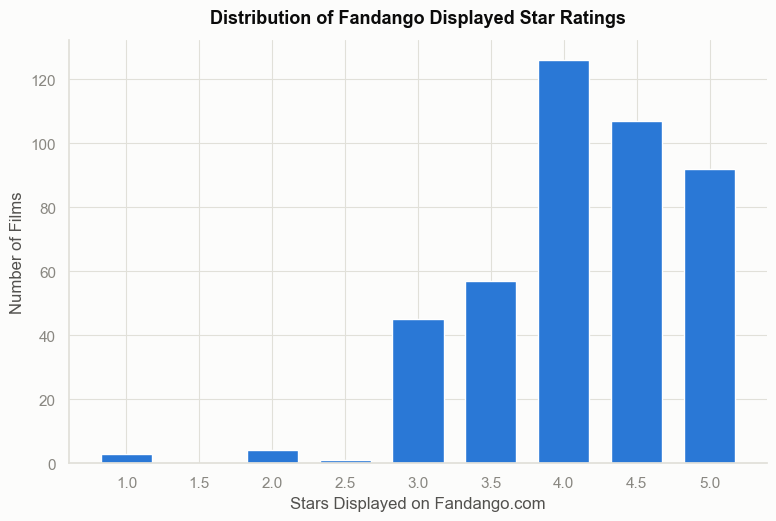

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))

counts = fan_reviewed['STARS'].value_counts().sort_index()
ax.bar(counts.index, counts.values, width=0.35, color=COLORS['blue'])

ax.set_title('Distribution of Fandango Displayed Star Ratings', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Stars Displayed on Fandango.com')
ax.set_ylabel('Number of Films')
ax.set_xticks(np.arange(1.0, 5.5, 0.5))

save_dashboard_figure(fig, '01_Ratings_Distribution.png')
plt.show()


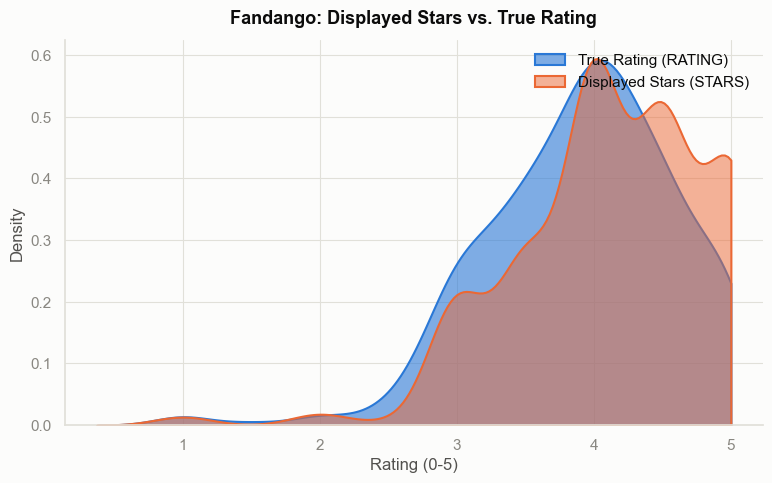

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.kdeplot(data=fan_reviewed, x='RATING', clip=(0, 5), fill=True, ax=ax,
            color=COLORS['blue'], label='True Rating (RATING)', alpha=0.6, linewidth=1.5)
sns.kdeplot(data=fan_reviewed, x='STARS', clip=(0, 5), fill=True, ax=ax,
            color=COLORS['orange'], label='Displayed Stars (STARS)', alpha=0.5, linewidth=1.5)

ax.set_title('Fandango: Displayed Stars vs. True Rating', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Rating (0-5)')
ax.set_ylabel('Density')
ax.legend(frameon=False)

save_dashboard_figure(fig, '02_KDE_Comparison.png')
plt.show()


## Part 3 — Comparing Fandango to other rating sites

Rotten Tomatoes, Metacritic, and IMDb don't score on a 0-5 scale, so every rating is
normalized onto Fandango's 0-5 star range before anything is compared. Only films that
appear in both source files are kept (an inner merge on `FILM`).


In [6]:
combined, norm_scores = normalize_scores(fandango, all_sites)
print("Films present on every platform:", len(combined))
norm_scores.head()


Films present on every platform: 145


,FILM,Fandango_STARS_norm,Fandango_RATING_norm,RT_norm,RT_user_norm,Meta_norm,Meta_user_norm,IMDB_norm
0,Fifty Shades of Grey (2015),4.0,3.9,1.25,2.10,2.30,1.60,2.10
1,Jurassic World (2015),4.5,4.5,3.55,4.05,2.95,3.50,3.65
2,American Sniper (2015),5.0,4.8,3.60,4.25,3.60,3.30,3.70
3,Furious 7 (2015),5.0,4.8,4.05,4.20,3.35,3.40,3.70
4,Inside Out (2015),4.5,4.5,4.90,4.50,4.70,4.45,4.30


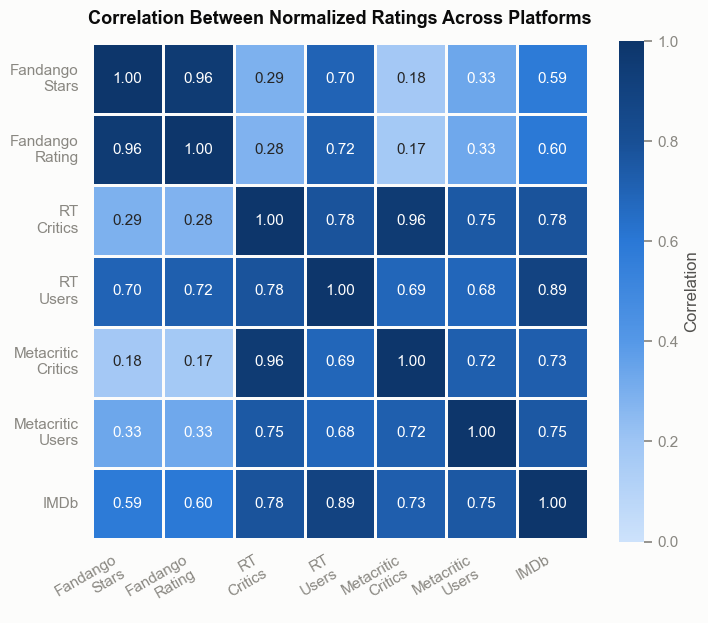

In [7]:
corr = norm_scores.drop(columns='FILM').corr()

blue_ramp = ['#cde2fb', '#9ec5f4', '#5598e7', '#2a78d6', '#184f95', '#0d366b']
cmap = LinearSegmentedColormap.from_list('blue_seq', blue_ramp)

labels = ['Fandango\nStars', 'Fandango\nRating', 'RT\nCritics', 'RT\nUsers',
          'Metacritic\nCritics', 'Metacritic\nUsers', 'IMDb']

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap, vmin=0, vmax=1,
            square=True, linewidths=2, linecolor='#fcfcfb',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Correlation'}, ax=ax)

ax.set_title('Correlation Between Normalized Ratings Across Platforms', fontsize=13, fontweight='bold', pad=14)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

save_dashboard_figure(fig, '03_Correlation.png')
plt.show()


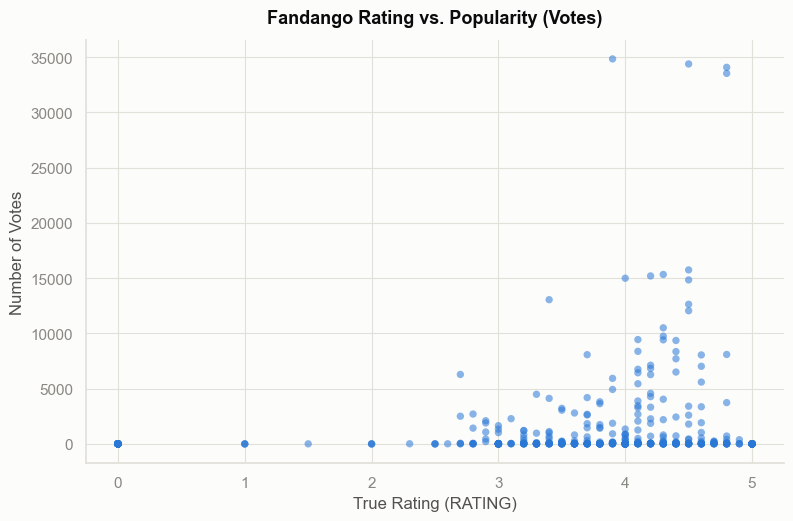

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(fandango['RATING'], fandango['VOTES'], s=28, alpha=0.55,
           color=COLORS['blue'], edgecolor='none')

ax.set_title('Fandango Rating vs. Popularity (Votes)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('True Rating (RATING)')
ax.set_ylabel('Number of Votes')

save_dashboard_figure(fig, '04_Scatter_Plot.png')
plt.show()


### Fandango vs. Rotten Tomatoes critics

Rotten Tomatoes critic scores are the most independent benchmark in the dataset (no
ticket-sales incentive). A regression line close to the dashed *"perfect agreement"*
diagonal would mean Fandango and RT critics broadly agree — a line sitting well above
the diagonal means Fandango rates the same films higher.


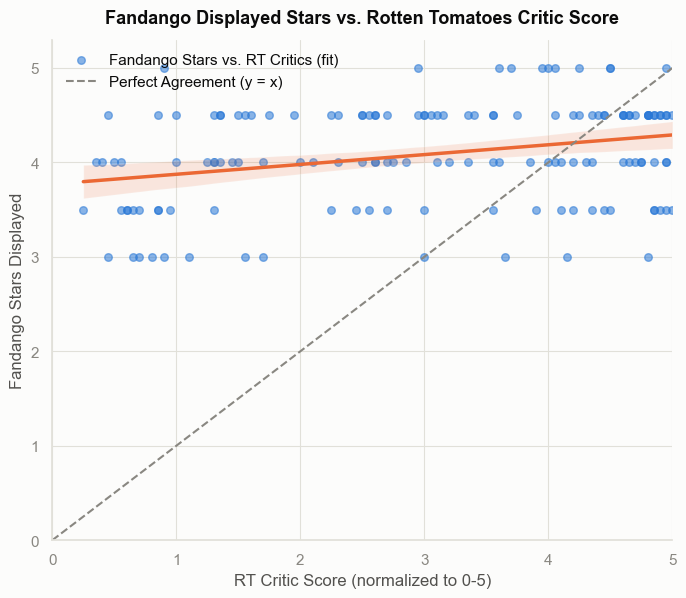

In [9]:
fig, ax = plt.subplots(figsize=(8, 6.5))

sns.regplot(data=combined, x='RT_norm', y='Fandango_STARS_norm', ax=ax,
            scatter_kws={'s': 30, 'alpha': 0.55, 'color': COLORS['blue']},
            line_kws={'color': COLORS['orange'], 'linewidth': 2.5},
            label='Fandango Stars vs. RT Critics (fit)')

lims = [0, 5]
ax.plot(lims, lims, linestyle='--', linewidth=1.5, color='#898781', label='Perfect Agreement (y = x)')

ax.set_xlim(0, 5)
ax.set_ylim(0, 5.3)
ax.set_title('Fandango Displayed Stars vs. Rotten Tomatoes Critic Score', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('RT Critic Score (normalized to 0-5)')
ax.set_ylabel('Fandango Stars Displayed')
ax.legend(frameon=False, loc='upper left')

save_dashboard_figure(fig, '05_Regression.png')
plt.show()


## Part 4 — Final insight

Averaging every normalized rating across all 145 shared films makes the bias explicit:
Fandango's displayed star average sits highest of any platform, while Rotten Tomatoes
and Metacritic critics — the two sources with no ticket-sales incentive — sit lowest.


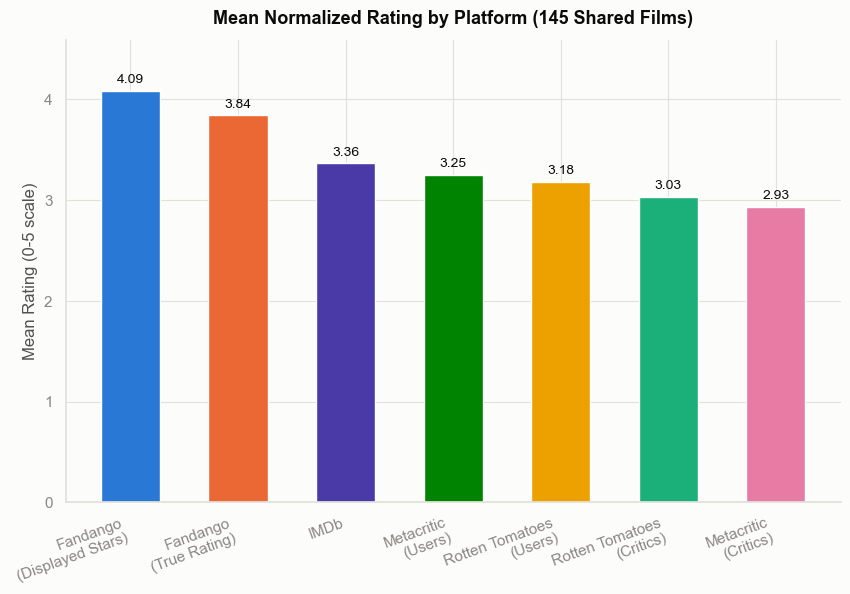

In [10]:
platform_cols = ['Fandango_STARS_norm', 'Fandango_RATING_norm', 'IMDB_norm',
                  'Meta_user_norm', 'RT_user_norm', 'RT_norm', 'Meta_norm']
platform_labels = {
    'Fandango_STARS_norm': 'Fandango\n(Displayed Stars)',
    'Fandango_RATING_norm': 'Fandango\n(True Rating)',
    'IMDB_norm': 'IMDb',
    'Meta_user_norm': 'Metacritic\n(Users)',
    'RT_user_norm': 'Rotten Tomatoes\n(Users)',
    'RT_norm': 'Rotten Tomatoes\n(Critics)',
    'Meta_norm': 'Metacritic\n(Critics)',
}
platform_colors = {
    'Fandango_STARS_norm': COLORS['blue'],
    'Fandango_RATING_norm': COLORS['orange'],
    'RT_norm': COLORS['aqua'],
    'RT_user_norm': COLORS['yellow'],
    'Meta_norm': COLORS['magenta'],
    'Meta_user_norm': COLORS['green'],
    'IMDB_norm': COLORS['violet'],
}

means = norm_scores[platform_cols].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar([platform_labels[c] for c in means.index], means.values,
              color=[platform_colors[c] for c in means.index], width=0.55)

for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.05, f'{val:.2f}',
            ha='center', va='bottom', fontsize=10, color='#0b0b0b')

ax.set_ylim(0, means.max() + 0.5)
ax.set_title('Mean Normalized Rating by Platform (145 Shared Films)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Mean Rating (0-5 scale)')
plt.xticks(rotation=20, ha='right')

save_dashboard_figure(fig, '06_Final_Insights.png')
plt.show()


## Conclusion

Fandango's displayed star rating averages **noticeably higher** than every other
platform in the dataset, and higher than its own true underlying `RATING` — a gap that
cannot be explained by rounding alone. Full write-up, methodology, and caveats are in
[`../Documentation/Findings.md`](../Documentation/Findings.md).
